## Predict Podcast Listening Time
### Playground Series - Season 5, Episode 4

**Rank:** 390 / 3310

- **Public Score:** 11.93393
- **Private Score:** 11.84268

I would like to express my gratitude to all the contributors in the discussions and notebooks sections, whose work inspired many of the ideas I implemented.

# PODCAST COMPETITION:

## 1. Data
## 2. EDA AND ANALYSIS
## 3. DATA Processing
## 4. Feature Engineering
## 5. LGB K FOLDS run


# DATA

In [1]:
!pip install -qq scikit-learn==1.6.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 80.6 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os 
from tqdm import tqdm
import warnings
import os
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
warnings.simplefilter('ignore')
from sklearn.preprocessing import LabelEncoder


plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
DEVICE = 'cuda'

In [3]:
original_df = pd.read_csv("/kaggle/input/podcast-listening-time-prediction-dataset/podcast_dataset.csv")
train_df = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv', index_col='id')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv', index_col='id')

# Concatenate original data with synthetics ones
train_df = pd.concat([train_df, original_df], axis=0, ignore_index=True)
train_df.drop_duplicates()

sample_submission = pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

print("\nData Info:")
train_df.info()

print("\nNumerical Features Summary:")
display(train_df.describe())

print("\nFirst 10 rows of Dataset:")
train_df.head(10)


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802500 entries, 0 to 802499
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 802500 non-null  object 
 1   Episode_Title                802500 non-null  object 
 2   Episode_Length_minutes       710161 non-null  float64
 3   Genre                        802500 non-null  object 
 4   Host_Popularity_percentage   802500 non-null  float64
 5   Publication_Day              802500 non-null  object 
 6   Publication_Time             802500 non-null  object 
 7   Guest_Popularity_percentage  651212 non-null  float64
 8   Number_of_Ads                802499 non-null  float64
 9   Episode_Sentiment            802500 non-null  object 
 10  Listening_Time_minutes       797105 non-null  float64
dtypes: float64(5), object(6)
memory usage: 67.3+ MB

Numerical Features Summary:


,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,710161.000000,802500.000000,651212.000000,802499.000000,797105.000000
mean,64.394865,59.879792,52.078083,1.358610,45.444668
std,32.983341,22.891991,28.488536,1.149546,27.140915
min,0.000000,1.300000,0.000000,0.000000,0.000000
25%,35.670000,39.460000,28.070000,0.000000,23.184220
50%,63.740000,60.060000,53.320000,1.000000,43.392270
75%,93.980000,79.560000,76.480000,2.000000,64.814620
max,325.240000,119.460000,119.910000,103.910000,119.970000



First 10 rows of Dataset:


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
5,Fitness First,Episode 19,26.54,Health,48.96,Saturday,Afternoon,NaN,3.0,Positive,22.77047
6,Criminal Minds,Episode 47,69.83,True Crime,35.82,Sunday,Night,39.02,0.0,Neutral,64.75024
7,News Roundup,Episode 44,48.52,News,44.99,Thursday,Night,20.12,0.0,Positive,22.37517
8,Daily Digest,Episode 32,105.87,News,69.81,Monday,Evening,NaN,2.0,Neutral,68.00124
9,Music Matters,Episode 81,NaN,Music,82.18,Thursday,Night,59.72,3.0,Neutral,45.94761


# EDA AND ANALYSIS

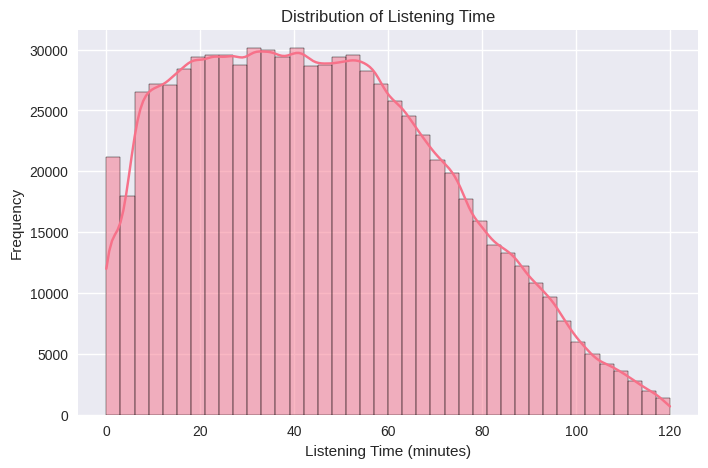

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df['Listening_Time_minutes'], kde=True, bins=40)
plt.title('Distribution of Listening Time')
plt.xlabel('Listening Time (minutes)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [5]:
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    print("\nMissing Values:")
    display(missing_values)
else:
    print("✅ No missing values found.")



Missing Values:


Guest_Popularity_percentage    151288
Episode_Length_minutes          92339
Listening_Time_minutes           5395
Number_of_Ads                       1
dtype: int64

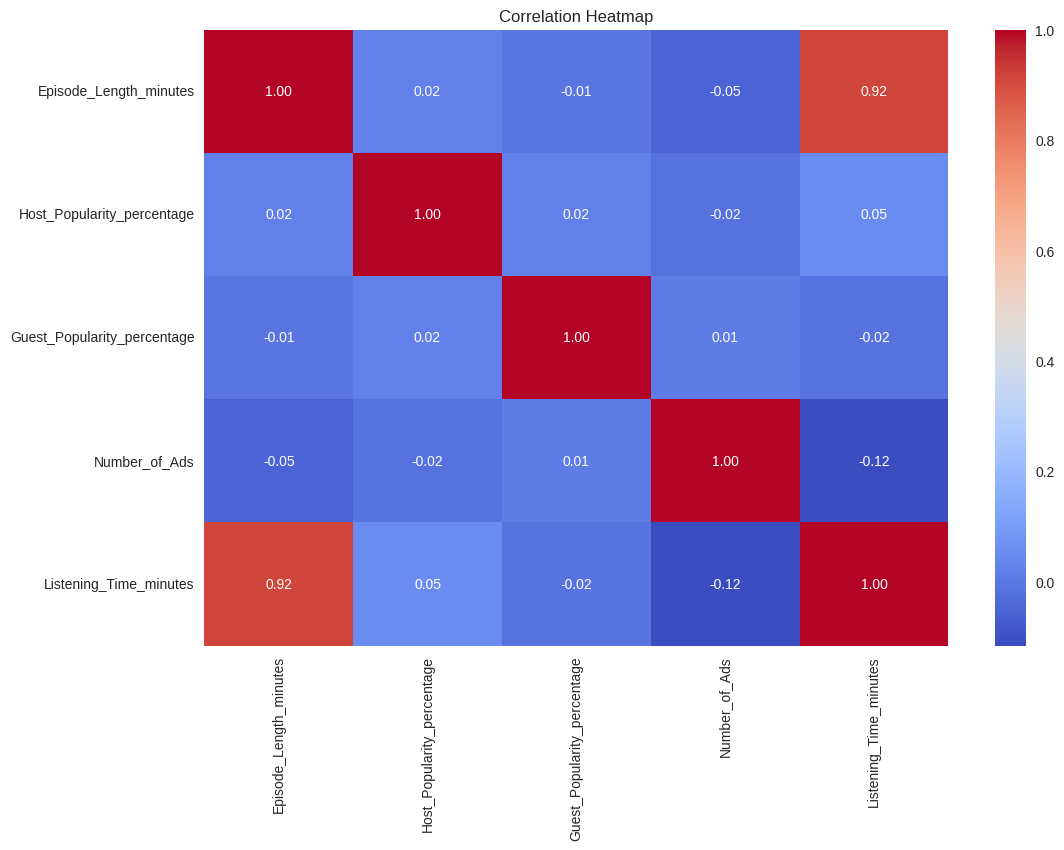

In [6]:
plt.figure(figsize=(12, 8))
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


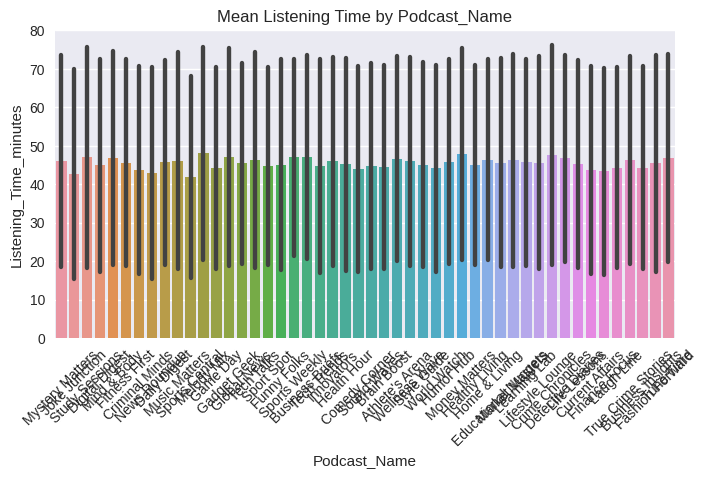

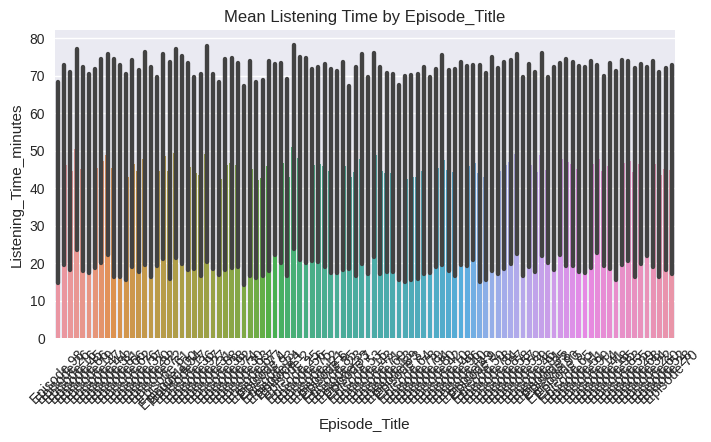

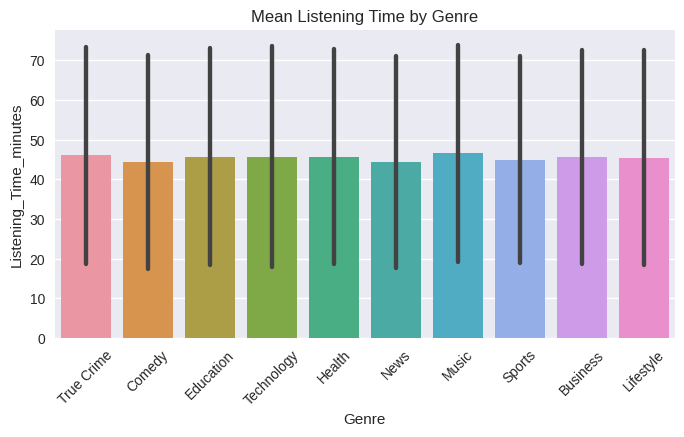

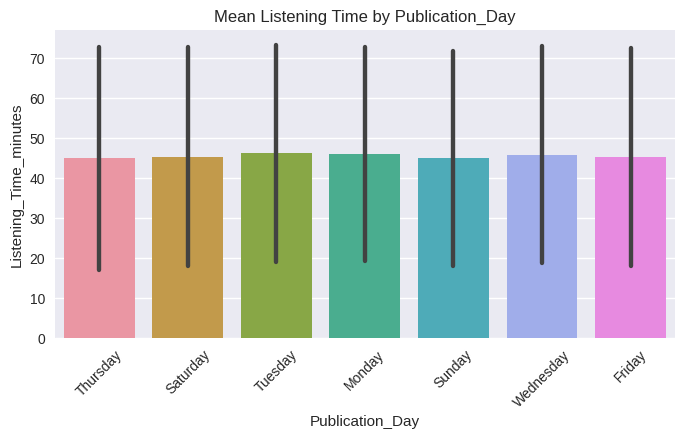

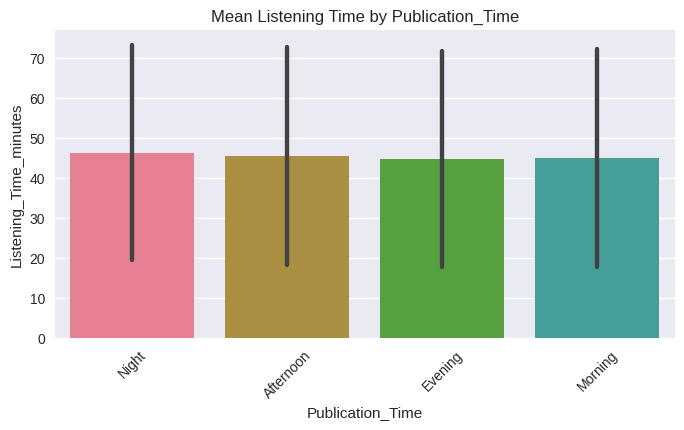

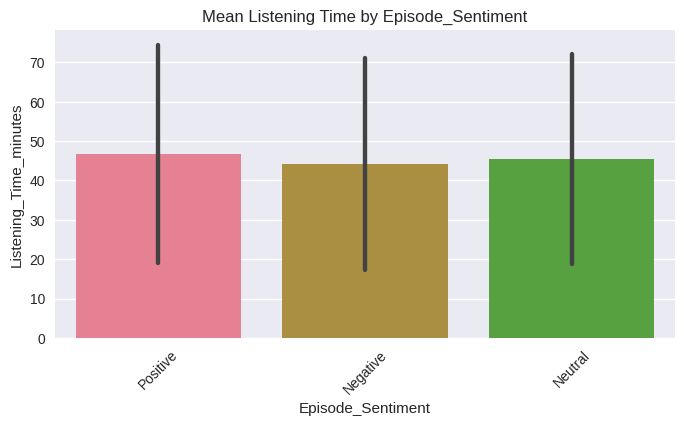

In [7]:
categorical_cols = train_df.select_dtypes(include='object').columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=train_df, x=col, y='Listening_Time_minutes', errorbar='sd')
    plt.xticks(rotation=45)
    plt.title(f"Mean Listening Time by {col}")
    plt.show()


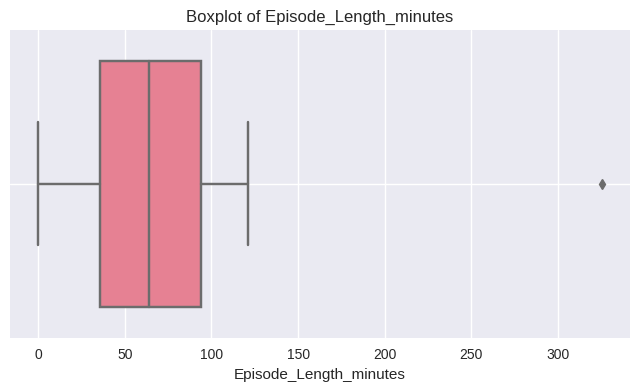

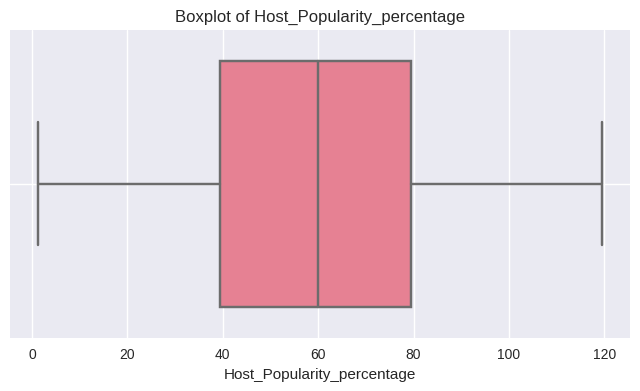

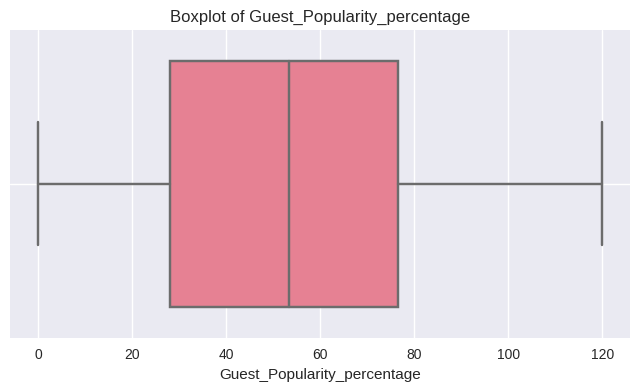

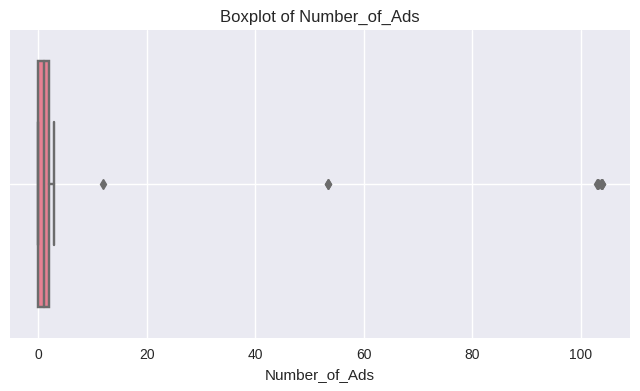

In [8]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop('Listening_Time_minutes')
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train_df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.grid(True)
    plt.show()


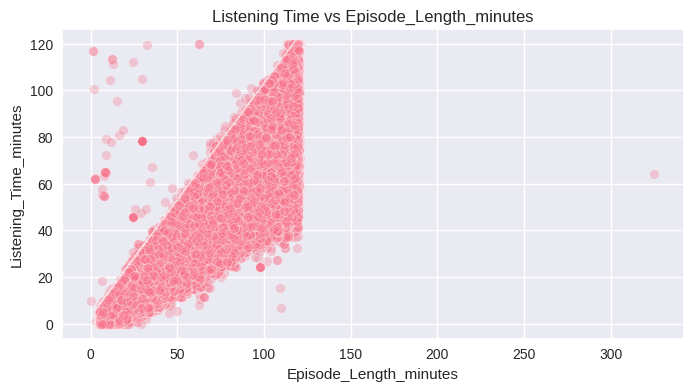

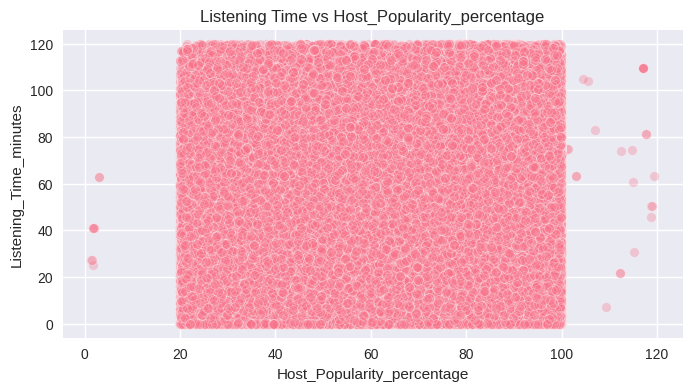

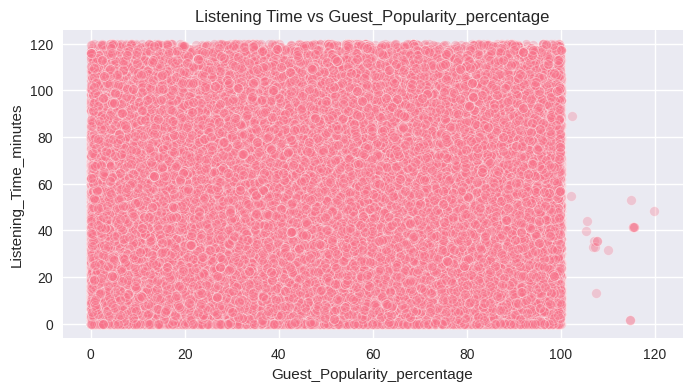

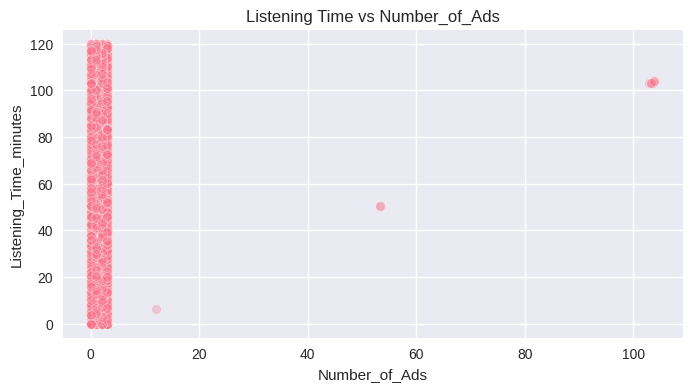

In [9]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=train_df, x=col, y='Listening_Time_minutes', alpha=0.3)
    plt.title(f"Listening Time vs {col}")
    plt.grid(True)
    plt.show()


# DATA HANDLING AND PROCESSING

In [10]:
# Deleting outliers 
# Outlier treatment
train_df['Episode_Length_minutes'] = np.clip(train_df['Episode_Length_minutes'], 0, 120)
train_df['Host_Popularity_percentage'] = np.clip(train_df['Host_Popularity_percentage'], 20, 100)
train_df['Guest_Popularity_percentage'] = np.clip(train_df['Guest_Popularity_percentage'], 0, 100)
train_df.loc[train_df['Number_of_Ads'] > 4, 'Number_of_Ads'] = 3

test_df['Episode_Length_minutes'] = np.clip(test_df['Episode_Length_minutes'], 0, 120)
test_df['Host_Popularity_percentage'] = np.clip(test_df['Host_Popularity_percentage'], 20, 100)
test_df['Guest_Popularity_percentage'] = np.clip(test_df['Guest_Popularity_percentage'], 0, 100)
test_df.loc[test_df['Number_of_Ads'] > 4, 'Number_of_Ads'] = 3

# First, fill NaNs in Guest_Popularity_percentage with 9999
train_df['Guest_Popularity_percentage'] = train_df['Guest_Popularity_percentage'].fillna(9999)
test_df['Guest_Popularity_percentage'] = test_df['Guest_Popularity_percentage'].fillna(9999)

# Then, create Has_Guest as binary flag: 1 if not 9999, else 0
train_df['Has_Guest'] = (train_df['Guest_Popularity_percentage'] != 9999).astype(int)
test_df['Has_Guest'] = (test_df['Guest_Popularity_percentage'] != 9999).astype(int)

# Replacing null values by median
train_df['Episode_Length_minutes'].fillna(train_df['Episode_Length_minutes'].median(), inplace=True)
test_df['Episode_Length_minutes'].fillna(train_df['Episode_Length_minutes'].median(), inplace=True)


# Feature Engineering

In [11]:
# NEW FEATURES 

train_df['has_NoAds'] = (train_df['Number_of_Ads'] == 0).astype(int)
train_df['has_many_ads'] = (train_df['Number_of_Ads'] > 2).astype(int)
train_df['long_episode'] = (train_df['Episode_Length_minutes'] > 70).astype(int)
train_df['ads_per_minute'] = train_df['Number_of_Ads'] / (train_df['Episode_Length_minutes'] + 1e-3)
train_df["Combined_Popularity"] = train_df["Host_Popularity_percentage"] + train_df["Guest_Popularity_percentage"]

test_df['has_NoAds'] = (test_df['Number_of_Ads'] == 0).astype(int)
test_df['has_many_ads'] = (test_df['Number_of_Ads'] > 2).astype(int)
test_df['long_episode'] = (test_df['Episode_Length_minutes'] > 70).astype(int)
test_df['ads_per_minute'] = test_df['Number_of_Ads'] / (test_df['Episode_Length_minutes'] + 1e-3)
test_df["Combined_Popularity"] = test_df["Host_Popularity_percentage"] + test_df["Guest_Popularity_percentage"]


In [12]:
# Analysing distributions of numerical features
numerical_features = [
    'Episode_Length_minutes', 
    'Host_Popularity_percentage',
    'Guest_Popularity_percentage', 
    'Number_of_Ads',
    'Listening_Time_minutes',
    'ads_per_minute', 
    'Combined_Popularity'
]

categorical_features = [
    'Podcast_Name', 
    'Genre', 
    'Publication_Day',
    'Publication_Time', 
    'Episode_Sentiment', 
    'Has_Guest', 
    'long_episode', 
    'has_NoAds', 
    'has_many_ads'
]

In [13]:
# Check for any remaining NaNs and show details
def check_missing(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"⚠️ {name} still contains missing values in the following columns:")
        print(missing)
    else:
        print(f"✅ {name}: no missing values remaining.")
check_missing(train_df, "X_train")
check_missing(test_df, "X_test")

⚠️ X_train still contains missing values in the following columns:
Number_of_Ads                1
Listening_Time_minutes    5395
ads_per_minute               1
dtype: int64
✅ X_test: no missing values remaining.


In [14]:
test_df = test_df.dropna()
train_df = train_df.dropna()
check_missing(train_df, "X_train")
check_missing(test_df, "X_test")

✅ X_train: no missing values remaining.
✅ X_test: no missing values remaining.


In [15]:
from sklearn.preprocessing import LabelEncoder

# Encoder for categorical data
label_encoders = {col: LabelEncoder() for col in categorical_features}

# Apply LabelEncoder to each categorical column
for col in categorical_features:
    train_df[col] = label_encoders[col].fit_transform(train_df[col])
    test_df[col] = label_encoders[col].transform(test_df[col])

    # Converting to category type 
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')


In [16]:
import gc
gc.collect()

11370

In [17]:
# creating most relevant feature 
train_df['Episode_Num'] = train_df['Episode_Title'].str[8:].astype('category')
test_df['Episode_Num'] = test_df['Episode_Title'].str[8:].astype('category')

train_df = train_df.drop(columns=['Episode_Title'])
test_df = test_df.drop(columns=['Episode_Title'])

In [18]:
train_df['Podcast_Name'].nunique()

48

**ALL COMBINATIONS BETWEEN Features of 2 to 4 combinations**

In [19]:
from tqdm import tqdm
from itertools import combinations
import gc

columns_to_encode = ['Episode_Length_minutes', 
                     'Episode_Num', 
                     'Host_Popularity_percentage', 
                     # 'Number_of_Ads', 
                     'Episode_Sentiment', 
                     'Publication_Day', 
                     'Publication_Time',
                     'Genre',
                     'Guest_Popularity_percentage',  
                     'has_many_ads', 
                     'long_episode', 
                     'ads_per_minute', 
                     'Combined_Popularity'
                    ]

pair_size = [2, 3] 
max_total_columns = 400  # Adjust this limit as needed

for r in pair_size: 
    combinations_list = list(combinations(columns_to_encode, r))
    batch_size = 20
    
    for i in range(0, len(combinations_list), batch_size):
        batch = combinations_list[i:i+batch_size]
        
        for cols in tqdm(batch):
            if len(train_df.columns) >= max_total_columns:
                print(f"Reached maximum column limit of {max_total_columns}. Stopping feature generation.")
                break  # Exit the inner loop

            new_col_name = '_'.join(cols)

            train_df[new_col_name] = train_df[list(cols)].astype(str).agg('_'.join, axis=1) 
            train_df[new_col_name] = train_df[new_col_name].astype('category')

            test_df[new_col_name] = test_df[list(cols)].astype(str).agg('_'.join, axis=1) 
            test_df[new_col_name] = test_df[new_col_name].astype('category')

        gc.collect()
        print(f"Memory usage: {train_df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")
        print(f"Total number of columns: {len(train_df.columns)}")

        if len(train_df.columns) >= max_total_columns:
            break  # Exit the outer batch loop too


 15%|█▌        | 3/20 [00:20<01:53,  6.70s/it]


Reached maximum column limit of 20. Stopping feature generation.
Memory usage: 170.40 MB
Total number of columns: 20


  0%|          | 0/20 [00:00<?, ?it/s]

Reached maximum column limit of 20. Stopping feature generation.
Memory usage: 170.40 MB
Total number of columns: 20


**Due to certain constraints(time and ressources), I decided to limit the exploration to just 3 combinations. However, I'm confident that including a 4th or even 5th combination could lead to improved performance, potentially reducing the RMSE to around 11.7. Still, the core idea is demonstrated effectively. This code would give you 11.85 in pvt.**

In [ ]:
# Save DataFrames
#train_df.to_csv("processed_train_df.csv", index=False)
#test_df.to_csv("processed_test_df.csv", index=False)
#print("Saved processed DataFrames to disk.")

In [20]:
X = train_df.drop(columns=['Listening_Time_minutes'])
y = train_df['Listening_Time_minutes']

In [21]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder
import lightgbm as lgb
import pandas as pd
import numpy as np
import gc

gc.collect()

# Prepare KFold and prediction accumulator
cv = KFold(5, random_state=42, shuffle=True)
y_pred = np.zeros(len(test_df))  # test_df must be already defined
sample_submission = pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

# Fold counter
fold_number = 0

for idx_train, idx_valid in cv.split(X, y):
    fold_number += 1
    
    # Split data
    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X.iloc[idx_valid], y.iloc[idx_valid]
    X_test = test_df[X.columns].copy()

    # Target encoding
    encoded_columns = train_df.columns[11:]
    encoder = TargetEncoder(random_state=42)

    X_train[encoded_columns] = encoder.fit_transform(X_train[encoded_columns], y_train)
    X_valid[encoded_columns] = encoder.transform(X_valid[encoded_columns])
    X_test[encoded_columns] = encoder.transform(X_test[encoded_columns])

    # Model
    model = lgb.LGBMRegressor(
        n_iter=1000,
        max_depth=-1,
        num_leaves=1024,
        colsample_bytree=0.7,
        learning_rate=0.03,
        objective='l2',
        metric='rmse',
        verbosity=-1,
        max_bin=1024,
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[
            lgb.log_evaluation(100),
            lgb.early_stopping(stopping_rounds=100)
        ],
    )

    # Predict and accumulate
    fold_pred = model.predict(X_test)
    y_pred += fold_pred
    
# Final averaged prediction
pred_lgbm = y_pred / 5

# Save final averaged submission
submission_lgbm = pd.DataFrame({
    'id': sample_submission.id,
    'Listening_Time_minutes': pred_lgbm
})
submission_lgbm.to_csv('submission_lgb.csv', index=False)
    

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 12.7322
[200]	valid_0's rmse: 12.6242
[300]	valid_0's rmse: 12.6097


KeyboardInterrupt: 